In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import plotly.express as px
movies=pd.read_csv("movies_updated.csv")
# movies.head(3)

In [2]:
# Exercise 1
# Display first five rows
print("=========First Five Rows=========")
display(movies.head())
print("$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$")

# Display number of rows and columns
print("Dataset Shape:")
print(movies.shape)

print(f"\nRows : {movies.shape[0]}")
print(f"Columns : {movies.shape[1]}")

print("$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$")
# Display column names
print("\nColumn Names")
print(movies.columns.tolist())
print("$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$")

# Display data types
print("\nData Types")
print(movies.dtypes)

=========First Five Rows=========


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,"runtime,,"
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772.0,Warner Bros.,"146.0,"
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106.0,Columbia Pictures,"104.0,"
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067.0,Lucasfilm,"124.0,"
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539.0,Paramount Pictures,"88.0,"
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344.0,Orion Pictures,"98.0,"


$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
Dataset Shape:
(4000, 15)

Rows : 4000
Columns : 15
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

Column Names
['name', 'rating', 'genre', 'year', 'released', 'score', 'votes', 'director', 'writer', 'star', 'country', 'budget', 'gross', 'company', 'runtime,,']
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

Data Types
name          object
rating        object
genre         object
year           int64
released      object
score        float64
votes          int64
director      object
writer        object
star          object
country       object
budget         int64
gross        float64
company       object
runtime,,     object
dtype: object


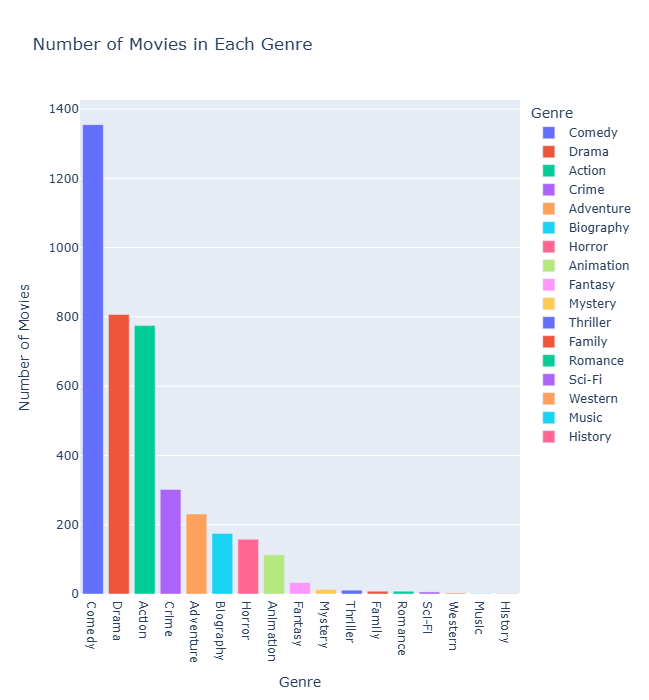

In [9]:
# Exercise 2
# Create a bar chart showing the number of movies in each genre
genre_count = movies["genre"].value_counts().reset_index()
genre_count.columns = ["Genre", "Number of Movies"]
fig = px.bar(
    genre_count,
    # X and Y axis label
    x="Genre",
    y="Number of Movies",
    # Different color for each Genre
    color="Genre",
    # Add chart title
    title="Number of Movies in Each Genre",
)
fig.update_layout(
 height=700
)
fig.show()


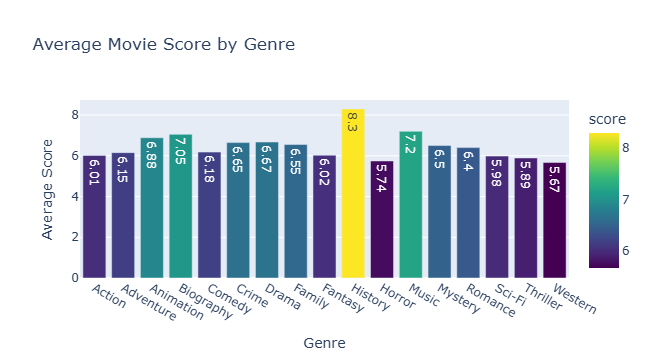

In [4]:
# Exercise 3
# Calculate the average movie score for each genre and create a bar chart.
# Requirements:
# Color the bars using the average score.
# Add a suitable chart title.
# Display genres on the x-axis.
avg_score = (movies.groupby("genre")["score"].mean().reset_index())
fig = px.bar(avg_score,x="genre",y="score",color="score",
    color_continuous_scale="Viridis",text=avg_score["score"].round(2),
    title="Average Movie Score by Genre"
)
fig.update_layout(
    xaxis_title="Genre",
    yaxis_title="Average Score",
    height=700
)
fig.show()


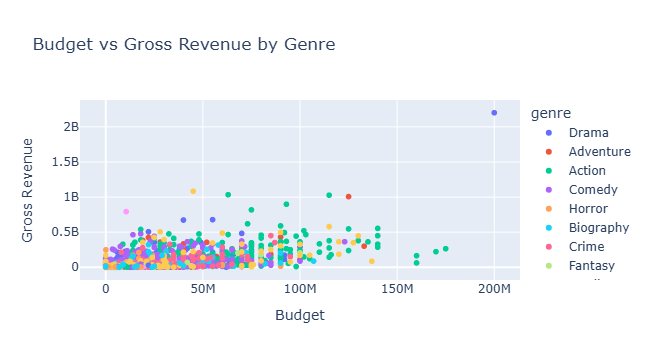

In [8]:
# Exercise 4
# Create a scatter plot showing the relationship between movie budget and gross revenue.
# Requirements:
# Color the points by genre.
# Display the movie name when hovering over a point.
# Add an appropriate chart title
scatter_data = movies.dropna(subset=["budget", "gross"])
fig = px.scatter(scatter_data,x="budget",y="gross",color="genre",
                 hover_name="name",
                 title="Budget vs Gross Revenue by Genre")
fig.update_layout(xaxis_title="Budget",
                  yaxis_title="Gross Revenue",
                  height=700
                 )
fig.show()

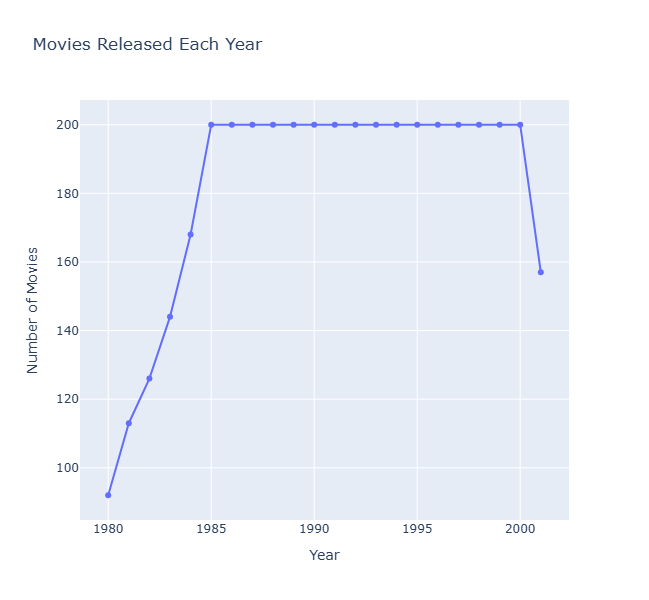

In [10]:
# Exercise 5
# Create a line chart showing the number of movies released each year.
# Requirements:
# Use markers.
# Add axis labels.
# Add a chart title.
movies_per_year = (movies.groupby("year").size()
    .reset_index(name="Number of Movies"))
fig = px.line(movies_per_year,x="year",y="Number of Movies",
    markers=True,title="Movies Released Each Year")
fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Number of Movies",
    height=600
)
fig.show()

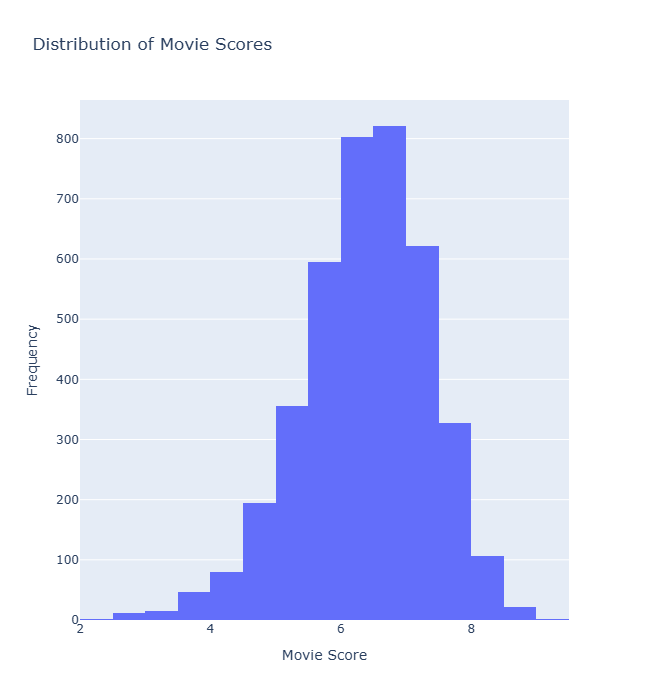

In [11]:
# Exercise 6
# Create a histogram showing the distribution of movie scores.
# Requirements:
# Choose an appropriate number of bins.
# Add a chart title
fig = px.histogram(
    movies,
    x="score",
    nbins=20,
    title="Distribution of Movie Scores"
)
fig.update_layout(
    xaxis_title="Movie Score",
    yaxis_title="Frequency",
    height=700
)
fig.show()

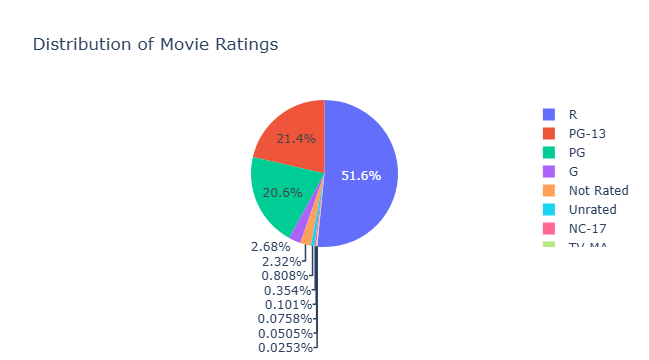

In [12]:
# Exercise 7
# Create a pie chart showing the distribution of movie ratings (PG, R, PG-13, etc.)
rating_count = (
    movies["rating"]
    .value_counts()
    .reset_index()
)
rating_count.columns = ["Rating", "Count"]
fig = px.pie(
    rating_count,
    names="Rating",
    values="Count",
    title="Distribution of Movie Ratings"
)
fig.show()

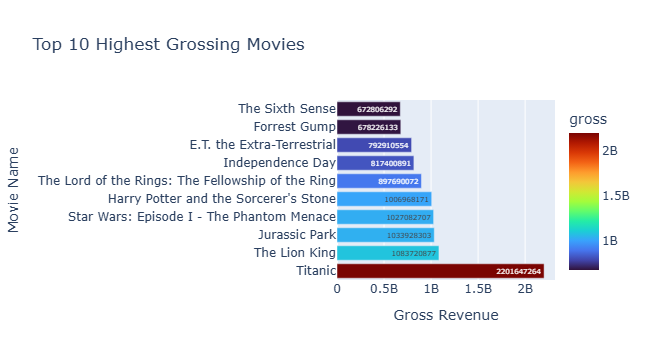

In [14]:
# Exercise 8
# Find the Top 10 Highest Grossing Movies and visualize the result using a horizontal bar
# chart.
# Requirements:
# Sort movies by gross revenue.
# Display movie names on the y-axis.
# Color the bars based on gross revenue.
top10 = (
    movies.sort_values("gross", ascending=False).head(10))
fig = px.bar(
    top10,x="gross",y="name",orientation="h",color="gross",
    color_continuous_scale="Turbo",text="gross",
    title="Top 10 Highest Grossing Movies"
)
fig.update_layout(
    xaxis_title="Gross Revenue",
    yaxis_title="Movie Name"
)
fig.show()